<a href="https://colab.research.google.com/github/gchekwemoi/OOP-python-assignment/blob/main/project1_population.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1: District Population Forecaster

## Purpose
Compare three forecasting models and estimate additional primary-school
classrooms needed by 2029.

## Data and assumptions
The population estimates for 2015–2024 are illustrative and measured
in thousands. They are not official UBOS figures.

The analysis includes Kampala, Wakiso and Gulu, plus two additional
districts with clearly labelled synthetic data.

For classroom planning, assume that 18% of the population is of
primary-school age and each classroom holds 53 pupils.

In [1]:
from pathlib import Path

# Download the repository if it is not already here.
if not Path("/content/OOP-python-assignment").exists():
    !git clone https://github.com/gchekwemoi/OOP-python-assignment.git

# Work inside the project folder.
%cd /content/OOP-python-assignment

# Show the files and folders.
!ls

/content/OOP-python-assignment
README.md  requirements.txt  src  tests


In [2]:
# List all project files, excluding Git's internal files.
!find . -maxdepth 3 -type f -not -path "./.git/*"

./README.md
./tests/__pycache__/__init__.cpython-313.pyc
./tests/__pycache__/test_population.cpython-313-pytest-8.4.2.pyc
./tests/src/population.py
./tests/__init__.py
./tests/test_population.py
./src/forecasting.py
./src/__pycache__/population.cpython-313.pyc
./src/__pycache__/forecasting.cpython-313.pyc
./src/__pycache__/__init__.cpython-313.pyc
./src/__init__.py
./src/population.py
./requirements.txt
./.pytest_cache/README.md
./.pytest_cache/.gitignore
./.pytest_cache/CACHEDIR.TAG


In [3]:
!git pull
!ls

Already up to date.
README.md  requirements.txt  src  tests


In [4]:
# Get the new population.py file from GitHub.
!git pull

# Import the class from our module.
from src.population import DistrictPopulation

# Create a Kampala object using the assignment's illustrative data.
kampala = DistrictPopulation(
    name="Kampala",
    years=list(range(2015, 2025)),
    populations=[1200, 1250, 1300, 1350, 1420,
                 1500, 1580, 1650, 1720, 1800]
)

print(kampala)
print("Number of observations:", len(kampala))
print("Years:", kampala.years)
print("Population (thousands):", kampala.populations)

Already up to date.
DistrictPopulation(name='Kampala', observations=10)
Number of observations: 10
Years: [2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
Population (thousands): [1200. 1250. 1300. 1350. 1420. 1500. 1580. 1650. 1720. 1800.]


In [5]:
years = list(range(2015, 2025))

wakiso = DistrictPopulation(
    "Wakiso", years,
    [950, 1000, 1070, 1150, 1220, 1300, 1390, 1480, 1570, 1670]
)

gulu = DistrictPopulation(
    "Gulu", years,
    [320, 330, 345, 360, 375, 390, 410, 430, 455, 480]
)

# Additional synthetic data for this exercise—not official estimates.
jinja = DistrictPopulation(
    "Jinja", years,
    [280, 288, 296, 305, 314, 324, 334, 344, 355, 366]
)

mbarara = DistrictPopulation(
    "Mbarara", years,
    [250, 260, 271, 282, 294, 306, 319, 332, 346, 360]
)

districts = [kampala, wakiso, gulu, jinja, mbarara]

for district in districts:
    print(district)

DistrictPopulation(name='Kampala', observations=10)
DistrictPopulation(name='Wakiso', observations=10)
DistrictPopulation(name='Gulu', observations=10)
DistrictPopulation(name='Jinja', observations=10)
DistrictPopulation(name='Mbarara', observations=10)


In [6]:
import statistics as stats
import numpy as np
import pandas as pd

rows = []

for district in districts:
    values = district.populations.tolist()

    rows.append({
        "District": district.name,
        "Mean (statistics)": stats.mean(values),
        "Mean (NumPy)": np.mean(values),
        "Median (statistics)": stats.median(values),
        "Median (NumPy)": np.median(values),
        "Variance (statistics)": stats.variance(values),
        "Variance (NumPy, ddof=1)": np.var(values, ddof=1),
        "Std dev (statistics)": stats.stdev(values),
        "Std dev (NumPy, ddof=1)": np.std(values, ddof=1),
        "Variance (NumPy default)": np.var(values)
    })

summary = pd.DataFrame(rows).set_index("District")
display(summary.round(2))

,Mean (statistics),Mean (NumPy),Median (statistics),Median (NumPy),Variance (statistics),"Variance (NumPy, ddof=1)",Std dev (statistics),"Std dev (NumPy, ddof=1)",Variance (NumPy default)
District,,,,,,,,,
Kampala,1477.0,1477.0,1460.0,1460.0,42601.11,42601.11,206.40,206.40,38341.00
Wakiso,1280.0,1280.0,1260.0,1260.0,60066.67,60066.67,245.09,245.09,54060.00
Gulu,389.5,389.5,382.5,382.5,2885.83,2885.83,53.72,53.72,2597.25
Jinja,320.6,320.6,319.0,319.0,842.93,842.93,29.03,29.03,758.64
Mbarara,302.0,302.0,300.0,300.0,1377.56,1377.56,37.12,37.12,1239.80


In [7]:
growth_rows = []
annual_growth = {}

for district in districts:
    population = district.populations

    # Percentage change from each previous year.
    growth = (population[1:] / population[:-1] - 1) * 100
    annual_growth[district.name] = growth

    # There are 9 annual intervals between 2015 and 2024.
    intervals = district.years[-1] - district.years[0]
    cagr = (
        (population[-1] / population[0]) ** (1 / intervals) - 1
    ) * 100

    growth_rows.append({
        "District": district.name,
        "CAGR (%)": cagr
    })

growth_table = pd.DataFrame(
    annual_growth,
    index=years[1:]
)
growth_table.index.name = "Year"

cagr_table = (
    pd.DataFrame(growth_rows)
    .set_index("District")
    .sort_values("CAGR (%)", ascending=False)
)

display(growth_table.round(2))
display(cagr_table.round(2))

,Kampala,Wakiso,Gulu,Jinja,Mbarara
Year,,,,,
2016,4.17,5.26,3.12,2.86,4.00
2017,4.00,7.00,4.55,2.78,4.23
2018,3.85,7.48,4.35,3.04,4.06
2019,5.19,6.09,4.17,2.95,4.26
2020,5.63,6.56,4.00,3.18,4.08
2021,5.33,6.92,5.13,3.09,4.25
2022,4.43,6.47,4.88,2.99,4.08
2023,4.24,6.08,5.81,3.20,4.22
2024,4.65,6.37,5.49,3.10,4.05


,CAGR (%)
District,
Wakiso,6.47
Kampala,4.61
Gulu,4.61
Mbarara,4.13
Jinja,3.02


**Interpretation of population growth**

Wakiso recorded the highest compound annual growth rate (CAGR),
at 6.47% between 2015 and 2024. Kampala and Gulu both recorded
4.61%, followed by Mbarara at 4.13% and Jinja at 3.02%.

Kampala and Gulu have the same CAGR because both populations
increased by 50% over the period. However, Kampala added
600,000 people, while Gulu added 160,000. Equal percentage
growth therefore does not imply equal additional demand
for classrooms.

These results describe illustrative data and should not be
interpreted as official district population growth estimates.


In [8]:
!git pull

from src.forecasting import (
    LinearForecaster,
    CAGRForecaster,
    FibonacciForecaster
)

model_classes = {
    "Linear": LinearForecaster,
    "CAGR": CAGRForecaster,
    "Fibonacci": FibonacciForecaster
}

comparison_tables = {}
selected_models = {}

for district in districts:
    # First 7 observations: 2015–2021.
    train_years = district.years[:7]
    train_population = district.populations[:7]

    # Last 3 observations: 2022–2024.
    actual = district.populations[7:]

    results = []

    for model_name, model_class in model_classes.items():
        model = model_class()
        model.fit(train_years, train_population)
        predicted = model.predict(horizon=3)

        errors = actual - predicted

        results.append({
            "Model": model_name,
            "MAE": np.mean(np.abs(errors)),
            "RMSE": np.sqrt(np.mean(errors ** 2)),
            "MAPE (%)": np.mean(np.abs(errors / actual)) * 100
        })

    table = pd.DataFrame(results).set_index("Model")
    comparison_tables[district.name] = table

    # Choose the model with the lowest MAE.
    best_name = table["MAE"].idxmin()
    selected_models[district.name] = best_name

    print(f"\n{district.name} — selected model: {best_name}")
    display(table.round(2))

Already up to date.

Kampala — selected model: CAGR


,MAE,RMSE,MAPE (%)
Model,,,
Linear,37.62,38.97,2.17
CAGR,9.62,10.39,0.55
Fibonacci,3543.33,4025.36,202.00



Wakiso — selected model: CAGR


,MAE,RMSE,MAPE (%)
Model,,,
Linear,49.4,52.37,3.09
CAGR,6.8,8.05,0.42
Fibonacci,3060.0,3479.87,189.87



Gulu — selected model: CAGR


,MAE,RMSE,MAPE (%)
Model,,,
Linear,18.57,20.29,4.01
CAGR,9.44,10.87,2.02
Fibonacci,911.67,1035.64,196.04



Jinja — selected model: CAGR


,MAE,RMSE,MAPE (%)
Model,,,
Linear,4.14,4.45,1.16
CAGR,0.68,0.83,0.19
Fibonacci,758.33,861.01,210.91



Mbarara — selected model: CAGR


,MAE,RMSE,MAPE (%)
Model,,,
Linear,5.36,5.73,1.53
CAGR,0.19,0.24,0.05
Fibonacci,717.33,814.90,203.94


In [9]:
forecasts = {}
fitted_models = {}
forecast_years = np.arange(2025, 2030)

for district in districts:
    best_name = selected_models[district.name]
    model = model_classes[best_name]()

    # Use all observations after completing model selection.
    model.fit(district.years, district.populations)

    fitted_models[district.name] = model
    forecasts[district.name] = model.predict(horizon=5)

forecast_table = pd.DataFrame(
    forecasts,
    index=forecast_years
)
forecast_table.index.name = "Year"

print("Forecast population — thousands of people")
display(forecast_table.round(2))

Forecast population — thousands of people


,Kampala,Wakiso,Gulu,Jinja,Mbarara
Year,,,,,
2025,1882.95,1778.03,502.12,377.06,374.89
2026,1969.72,1893.04,525.26,388.45,390.39
2027,2060.49,2015.49,549.46,400.18,406.53
2028,2155.44,2145.86,574.78,412.27,423.34
2029,2254.76,2284.67,601.27,424.72,440.84


In [10]:
planning_rows = []

for district in districts:
    population_2024 = district.populations[-1]
    population_2029 = forecasts[district.name][-1]

    # Convert population from thousands to people.
    additional_people = (population_2029 - population_2024) * 1000
    additional_pupils = max(0, additional_people * 0.18)

    # Round up because a fraction of a classroom is insufficient.
    additional_classrooms = int(np.ceil(additional_pupils / 53))

    planning_rows.append({
        "District": district.name,
        "2024 population (thousands)": population_2024,
        "2029 population (thousands)": population_2029,
        "Additional primary-age children": additional_pupils,
        "Additional classrooms": additional_classrooms
    })

planning_table = pd.DataFrame(planning_rows).set_index("District")
display(planning_table.round(2))

,2024 population (thousands),2029 population (thousands),Additional primary-age children,Additional classrooms
District,,,,
Kampala,1800.0,2254.76,81857.42,1545
Wakiso,1670.0,2284.67,110640.73,2088
Gulu,480.0,601.27,21828.64,412
Jinja,366.0,424.72,10570.00,200
Mbarara,360.0,440.84,14551.32,275


In [11]:
variance_rows = []

for district in districts:
    variance_rows.append({
        "District": district.name,
        "Actual variance (2015–2024)": np.var(
            district.populations, ddof=1
        ),
        "Forecast variance (2025–2029)": np.var(
            forecasts[district.name], ddof=1
        )
    })

variance_table = pd.DataFrame(variance_rows).set_index("District")
display(variance_table.round(2))

,Actual variance (2015–2024),Forecast variance (2025–2029)
District,,
Kampala,42601.11,21607.68
Wakiso,60066.67,40131.36
Gulu,2885.83,1536.55
Jinja,842.93,355.06
Mbarara,1377.56,679.87


## Interpreting the variance comparison

Both variances measure the spread of population levels and use
ddof=1. Their units are (thousands of people)².

The historical series covers ten years, while the forecast covers
five. A lower forecast variance may therefore reflect the shorter
period and the smooth model-generated values. It does not establish
that future population is more stable or that predictions are
more certain.

These variances describe variation across years, not forecast
uncertainty. Prediction intervals are needed to describe uncertainty
around the forecasts.

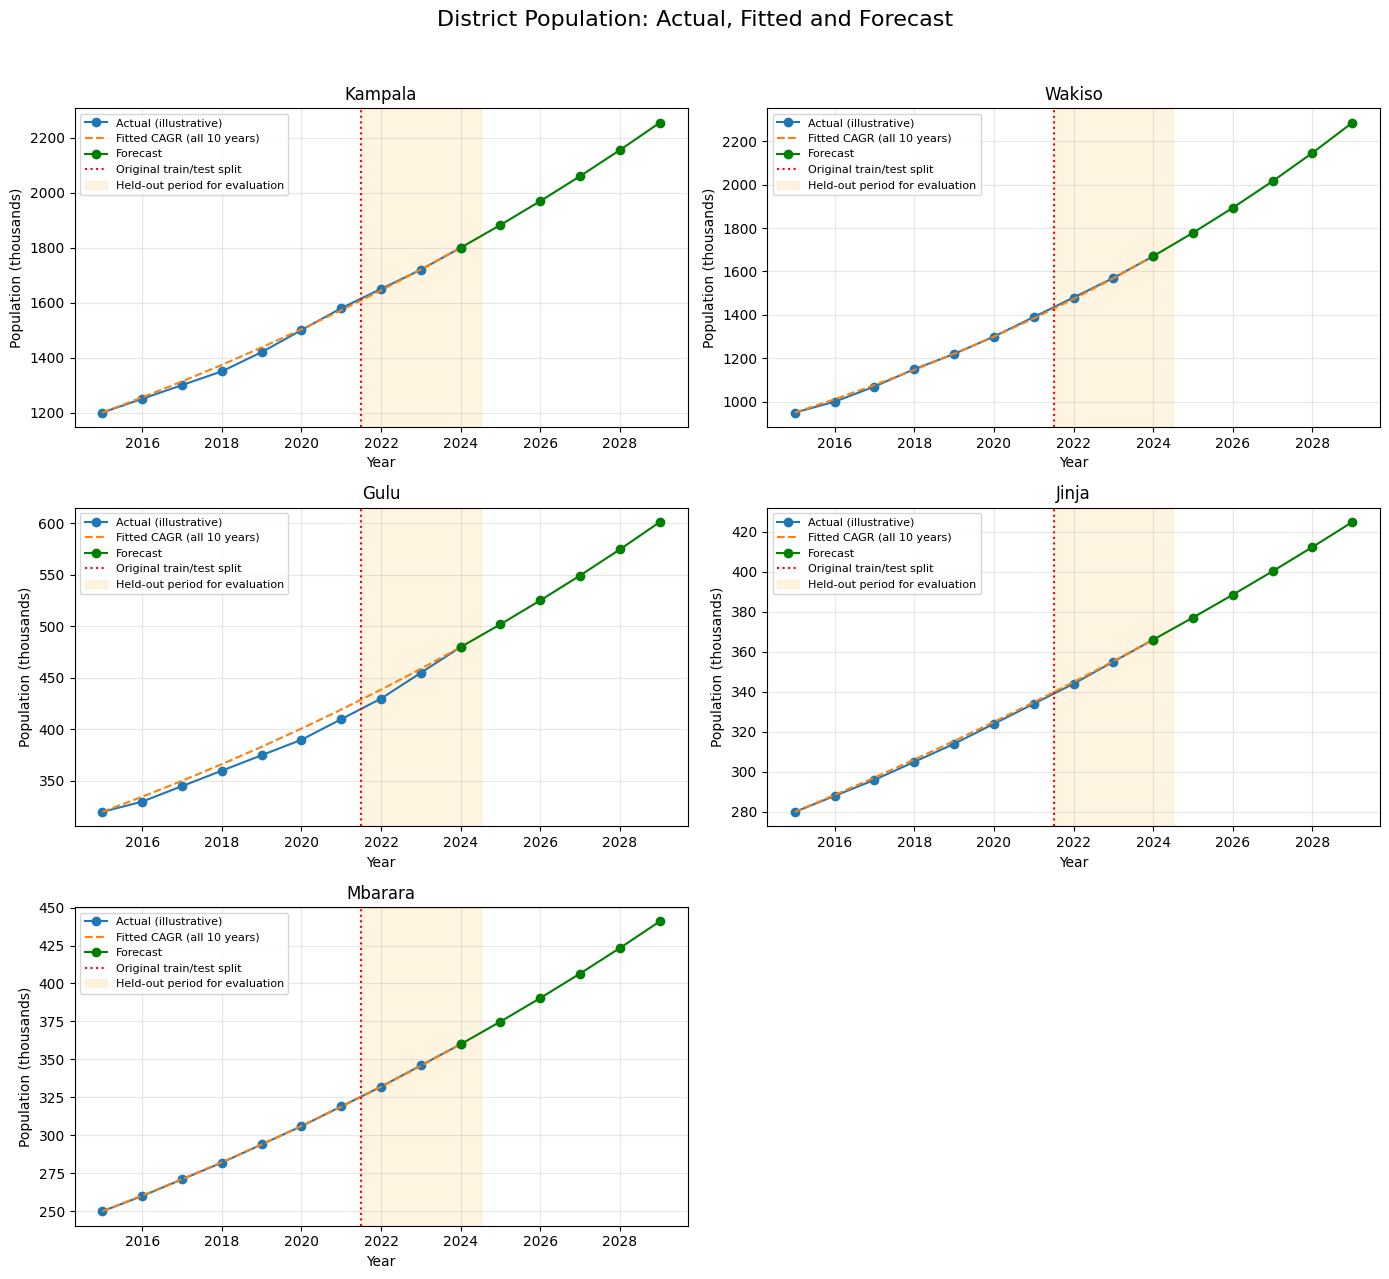

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(14, 13))
axes = axes.flatten()

for ax, district in zip(axes, districts):
    model = fitted_models[district.name]

    # Historical curve implied by the refitted CAGR model.
    fitted = district.populations[0] * (
        model.growth_factor
        ** (district.years - district.years[0])
    )

    ax.plot(
        district.years, district.populations,
        "o-", label="Actual (illustrative)"
    )

    ax.plot(
        district.years, fitted,
        "--", label="Fitted CAGR (all 10 years)"
    )

    # Include 2024 to connect the forecast to the last observation.
    ax.plot(
        np.concatenate(([2024], forecast_years)),
        np.concatenate((
            [district.populations[-1]],
            forecasts[district.name]
        )),
        "o-", color="green", label="Forecast"
    )

    ax.axvline(
        2021.5, color="red", linestyle=":",
        label="Original train/test split"
    )

    ax.axvspan(
        2021.5, 2024.5, color="orange", alpha=0.12,
        label="Held-out period for evaluation"
    )

    ax.set_title(district.name)
    ax.set_xlabel("Year")
    ax.set_ylabel("Population (thousands)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

# Hide the unused sixth panel.
axes[-1].set_visible(False)

fig.suptitle(
    "District Population: Actual, Fitted and Forecast",
    fontsize=16
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [13]:
!git pull
!python -m pip install -q pytest
!python -m pytest tests/test_population.py -q

Already up to date.
......                                                                   [100%]
6 passed in 0.10s


## Findings & Limitations

The CAGR model produced the lowest MAE, RMSE and MAPE for all
five districts when trained on 2015–2021 and evaluated on
2022–2024. It therefore provided the strongest forecasting
performance among the three models for these illustrative data.
Wakiso had the highest historical CAGR, at 6.47%, suggesting
the greatest proportional increase in demand for school places.

After refitting the selected models on 2015–2024, projected
2029 populations were approximately 2.285 million for Wakiso
and 2.255 million for Kampala. Assuming that 18% of residents
are of primary-school age and each classroom accommodates
53 pupils, growth from 2024 implies 2,088 additional classrooms
in Wakiso, 1,545 in Kampala, 412 in Gulu, 200 in Jinja and
275 in Mbarara. These estimates assume existing capacity
already meets 2024 needs.

The Fibonacci model substantially overestimated population.
Its successive ratios approach 1.618, implying approximately
61.8% annual growth, which is unsupported by these series.
Such a model would require evidence of that growth pattern
over the forecast period.

The data are synthetic, and evaluation covers only three years.
CAGR assumes unchanged percentage growth and excludes migration,
policy changes and demographic shocks. Lower forecast variance
does not establish lower uncertainty. Classroom estimates also
exclude existing shortages, enrolment differences and local
variation in class sizes. Official data and uncertainty analysis
are needed before using these results for planning.

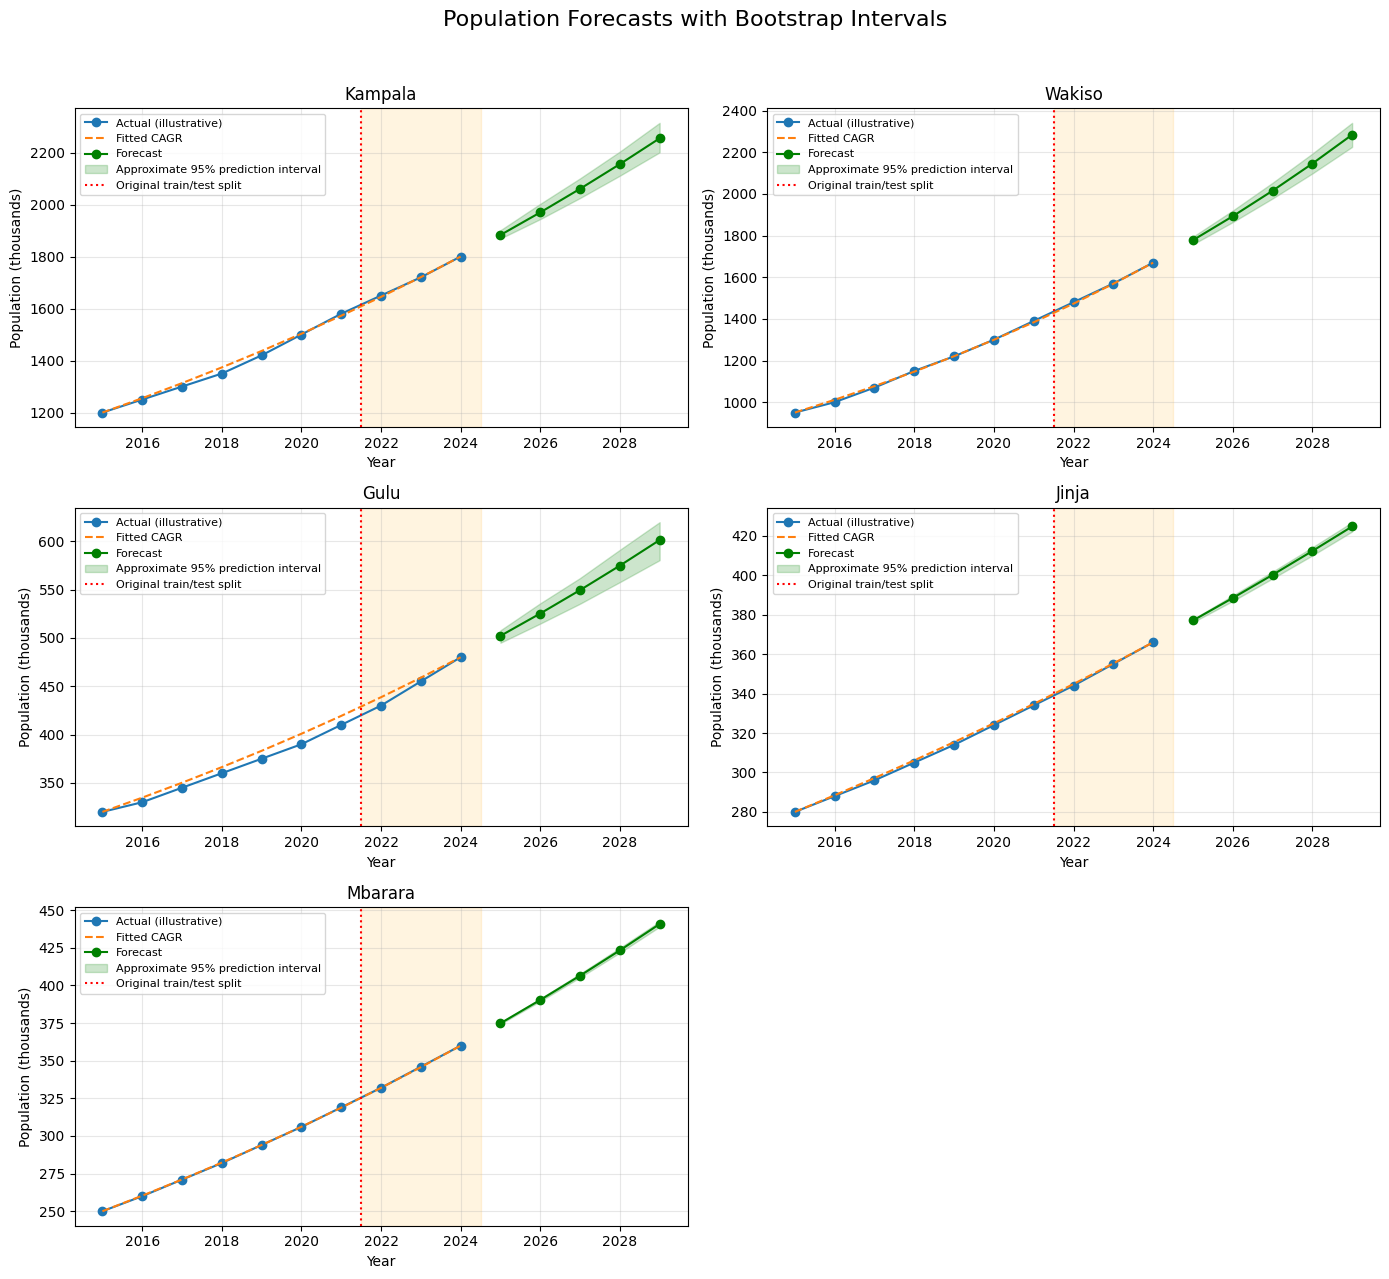

In [14]:
rng = np.random.default_rng(42)
prediction_intervals = {}

fig, axes = plt.subplots(3, 2, figsize=(14, 13))
axes = axes.flatten()

for ax, district in zip(axes, districts):
    model = fitted_models[district.name]

    # Residuals from the CAGR model's annual log-growth assumption.
    observed_log_growth = np.diff(np.log(district.populations))
    residuals = observed_log_growth - np.log(model.growth_factor)
    residuals = residuals - residuals.mean()

    # Sample five future annual residuals for each of 1,000 paths.
    sampled_residuals = rng.choice(
        residuals, size=(1000, 5), replace=True
    )

    simulated_log_growth = (
        np.log(model.growth_factor) + sampled_residuals
    )

    simulated_populations = district.populations[-1] * np.exp(
        np.cumsum(simulated_log_growth, axis=1)
    )

    lower, upper = np.percentile(
        simulated_populations, [2.5, 97.5], axis=0
    )
    prediction_intervals[district.name] = (lower, upper)

    fitted = district.populations[0] * (
        model.growth_factor
        ** (district.years - district.years[0])
    )

    ax.plot(
        district.years, district.populations,
        "o-", label="Actual (illustrative)"
    )
    ax.plot(
        district.years, fitted,
        "--", label="Fitted CAGR"
    )
    ax.plot(
        forecast_years, forecasts[district.name],
        "o-", color="green", label="Forecast"
    )
    ax.fill_between(
        forecast_years, lower, upper,
        color="green", alpha=0.2,
        label="Approximate 95% prediction interval"
    )

    ax.axvline(
        2021.5, color="red", linestyle=":",
        label="Original train/test split"
    )
    ax.axvspan(2021.5, 2024.5, color="orange", alpha=0.12)

    ax.set_title(district.name)
    ax.set_xlabel("Year")
    ax.set_ylabel("Population (thousands)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
fig.suptitle("Population Forecasts with Bootstrap Intervals", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Bootstrap interval assumptions

We generated 1,000 future paths by resampling centred annual
log-growth residuals, using a fixed random seed of 42.
The shaded bands show the 2.5th and 97.5th percentiles at each
forecast year.

These approximate prediction intervals assume that future growth
disturbances resemble historical disturbances and are independent
across years. They hold the estimated CAGR fixed, excluding
parameter uncertainty and structural changes. With only nine
historical growth observations and smooth synthetic data, the
bands may understate real-world uncertainty.